<a href="https://colab.research.google.com/github/shahhelly1307-arch/Sqrock-Data-Science-week2-task2/blob/main/Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Load the data
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Handle missing TotalCharges (The file found 11 NAs)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# Convert Churn to 1 and 0
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

/tmp/ipykernel_20242/1810281061.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


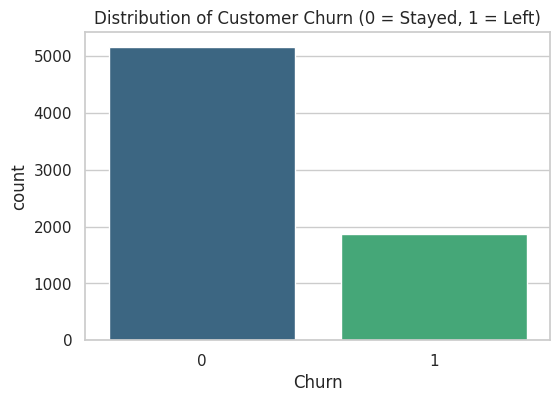

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set(style="whitegrid")

# Plot Churn Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribution of Customer Churn (0 = Stayed, 1 = Left)')
plt.show()

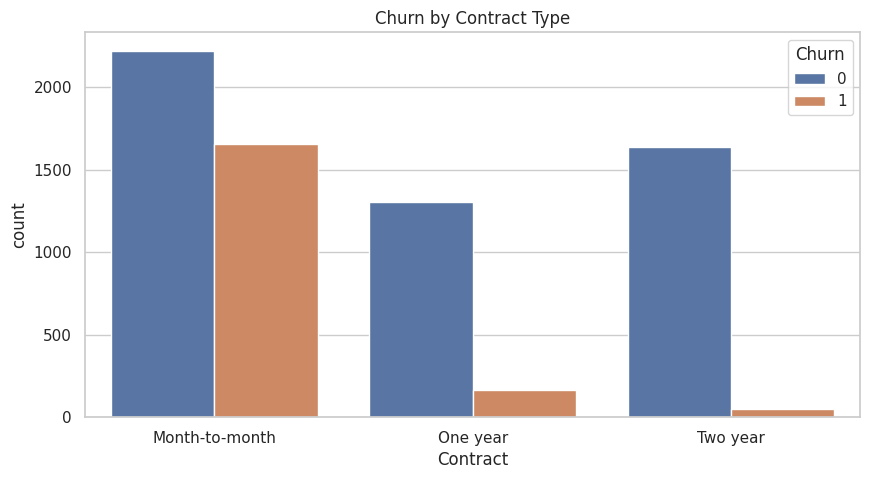

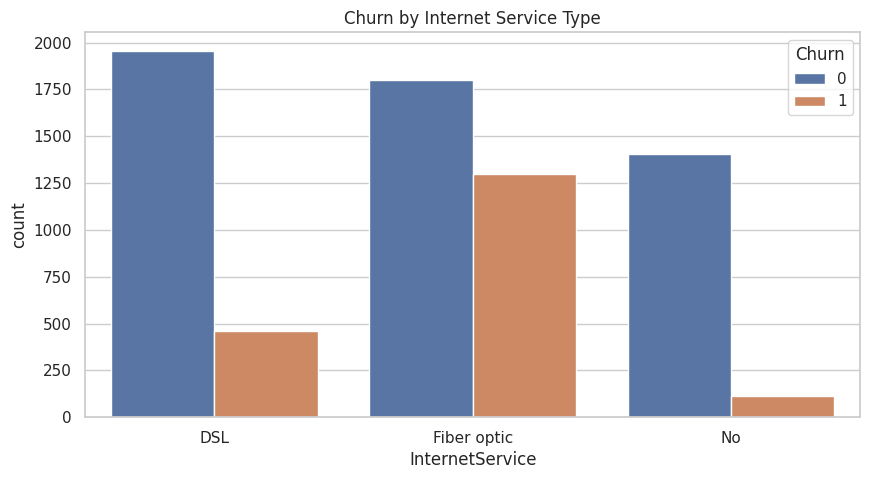

In [ ]:
# 1. Churn by Contract Type
plt.figure(figsize=(10, 5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.show()

# 2. Churn by Internet Service
plt.figure(figsize=(10, 5))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('Churn by Internet Service Type')
plt.show()

In [ ]:
# Drop CustomerID as it is useless for prediction
df.drop('customerID', axis=1, inplace=True)

# Create dummy variables for all categorical text columns
df_final = pd.get_dummies(df)

# Check the new columns
print(df_final.head())

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Female  \
0              0       1           29.85         29.85      0           True   
1              0      34           56.95       1889.50      0          False   
2              0       2           53.85        108.15      1          False   
3              0      45           42.30       1840.75      0          False   
4              0       2           70.70        151.65      1           True   

   gender_Male  Partner_No  Partner_Yes  Dependents_No  ...  \
0        False       False         True           True  ...   
1         True        True        False           True  ...   
2         True        True        False           True  ...   
3         True        True        False           True  ...   
4        False        True        False           True  ...   

   StreamingMovies_Yes  Contract_Month-to-month  Contract_One year  \
0                False                     True              False   


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Define X (features) and y (target)
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

# Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and Train the Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make Predictions
predictions = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy Score: 0.7882018479033405

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



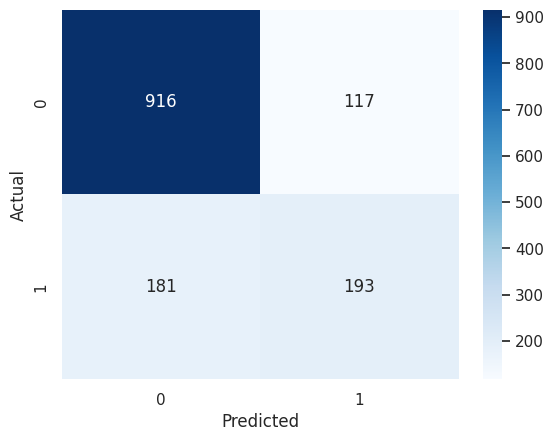

In [ ]:
print("Accuracy Score:", accuracy_score(y_test, predictions))
print("\nClassification Report:\n", classification_report(y_test, predictions))

# Visualize the Confusion Matrix
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions and Score
rf_predictions = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))

Random Forest Accuracy: 0.7775408670931059


/tmp/ipykernel_20242/3762032182.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


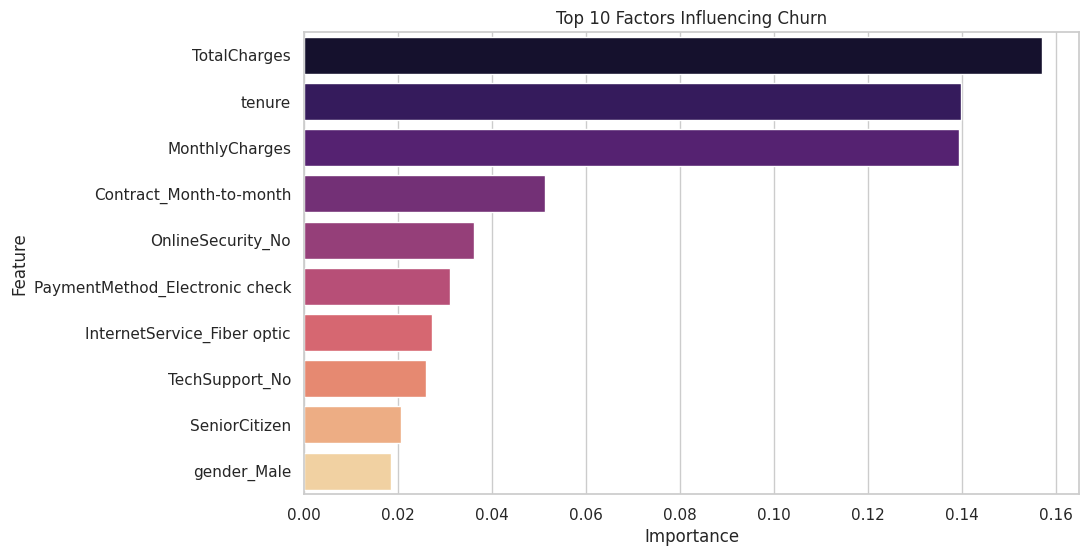

In [ ]:
# Get Feature Importances
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Top 10 Factors Influencing Churn')
plt.show()

📊 Business Insights & Recommendations
Insight: High Monthly Charges and "Month-to-Month" contracts are the strongest predictors of churn.

Insight: Customers with "Fiber Optic" internet churn more than those with DSL, suggesting possible service quality issues or pricing dissatisfaction in that segment.

Recommendation: To reduce churn, the marketing team should offer incentives (discounts or extra data) to "Month-to-Month" customers to switch to 1-year or 2-year contracts.

Recommendation: Target "Senior Citizens" with specialized tech support packages, as they show a higher tendency to leave when they face technical hurdles.

In [ ]:
import joblib

# Check if rf_model exists, if not, we use the model name from your notebook
try:
    joblib.dump(rf_model, 'churn_model.pkl')
    print("Success: churn_model.pkl has been created!")
except NameError:
    # In your uploaded notebook, the model was named 'model.rf'
    joblib.dump(model.rf, 'churn_model.pkl')
    print("Success: churn_model.pkl has been created using model.rf!")

Success: churn_model.pkl has been created!


In [ ]:
import joblib
joblib.dump(rf_model, 'churn_model.pkl')
print("Success! File created.")

Success! File created.


In [ ]:
import joblib
# This creates the file in Colab's memory
joblib.dump(rf_model, 'churn_model.pkl')
print("The file has been created successfully!")

The file has been created successfully!


In [ ]:
import joblib
# This creates the file in Colab's memory
joblib.dump(rf_model, 'churn_model.pkl')
print("The file has been created successfully!")

The file has been created successfully!
